# Notebook 9 – Outlier Detection

### What are Outliers?

An outlier is a data value that is very different from the other values in a dataset

Example:-

Consider:

10, 12, 11, 13, 12, 14, 100

Most values are between 10 and 14, but 100 is very far away.

Therefore:

100 → Outlier

An **outlier** is a data value that is significantly different from the other values in a dataset.

**Example:**

10, 12, 11, 13, 12, 14, 100

Here, **100 is an outlier** because it is much larger than the other values.

In [1]:
data = [10, 12, 11, 13, 12, 14, 100]      #Pythonimplementation

print(data)

[10, 12, 11, 13, 12, 14, 100]


### Types of Outliers

1. Point Outlier

A point outlier is one individual value that is very different from the rest

Example:

10, 12, 11, 13, 12, 100

Here:

100 → Point outlier

2. Contextual Outlier

A value may be considered an outlier depending on the context.

Example:

Temperature = 45°C

45°C may be normal in some locations during summer, but unusual in another context.

3. Collective Outlier

A group of observations together behaves unusually.

For example, a sudden sequence of unusual transactions could indicate abnormal behaviour.


### Detecting Outliers

There are several methods for detecting outliers.

The two important methods in this notebook are:

1. IQR Method
2. Z-Score Method

We can also use visual methods:

3. Box Plot
4. Scatter Plot

### IQR Method

IQR means Interquartile Range

It measures the spread of the middle 50% of the data.

Formula:


$$
IQR = Q_3 - Q_1
$$

Where:

- $Q_1$ = First Quartile
- $Q_3$ = Third Quartile
- $IQR$ = Interquartile Range

Outlier Formula

The lower and upper boundaries are:

$$
Lower\ Bound = Q_1 - 1.5(IQR)
$$

$$
Upper\ Bound = Q_3 + 1.5(IQR)
$$

Any value:

$$ < Lower\ Bound $$

or

$$ > Upper\ Bound $$

is considered an outlier using the IQR rule


Numerical Example:

Consider:

10, 12, 13, 14, 15, 16, 18, 20, 100

Suppose:

$$ Q_1 = 13 $$ $$ Q_3 = 18 $$

Then:

$$ IQR = Q_3-Q_1 $$ $$ IQR = 18-13=5 $$

Lower Bound

$$ 13-(1.5\times5) $$ $$ =13-7.5 $$ $$ =5.5 $$

Upper Bound

$$ 18+(1.5\times5) $$ $$ =18+7.5 $$ $$ =25.5 $$

Therefore, any value greater than 25.5 is an outlier.

So:

100 → Outlier

In [2]:
import numpy as np                    #Pythonimplementaion

data = [10, 12, 13, 14, 15, 16, 18, 20, 100]

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 13.0
Q3: 18.0
IQR: 5.0
Lower Bound: 5.5
Upper Bound: 25.5


In [3]:
outliers = [x for x in data if x < lower_bound or x > upper_bound]

print("Outliers:", outliers)

Outliers: [100]


### Z-Score Method

A Z-score tells us how many standard deviations a value is away from the mean

Formula:

$$
Z = \frac{X-\mu}{\sigma}
$$

Where:

- $X$ = Data value
- $\mu$ = Mean
- $\sigma$ = Standard deviation
- $Z$ = Z-score


A common rule is:

|Z| > 3 → Potential outlier

That means:

$$ Z > 3 $$

or

$$ Z < -3 $$

may indicate an outlier

This is a rule of thumb, not a universal law; the appropriate threshold depends on the data and assumptions

In [4]:
import numpy as np                         #pythonimplementation
from scipy.stats import zscore

data = np.array([10, 12, 13, 14, 15, 16, 18, 20, 100])

z_scores = zscore(data)

print("Z-Scores:")
print(z_scores)

Z-Scores:
[-0.52785413 -0.45362464 -0.4165099  -0.37939515 -0.34228041 -0.30516567
 -0.23093618 -0.15670669  2.81247277]


In [5]:
outliers = data[np.abs(z_scores) > 3]         #Detectoutliers

print("Outliers:", outliers)

Outliers: []


### Box Plot

A box plot is a graphical method for identifying the distribution of numerical data and possible outliers
It gives us a quick visual way to identify potential outliers

It shows:

Minimum
Q1
Median
Q3
Maximum

Simple Structure:

Minimum ── Q1 ── Median ── Q3 ── Maximum
                    |
                 Middle
                  50%

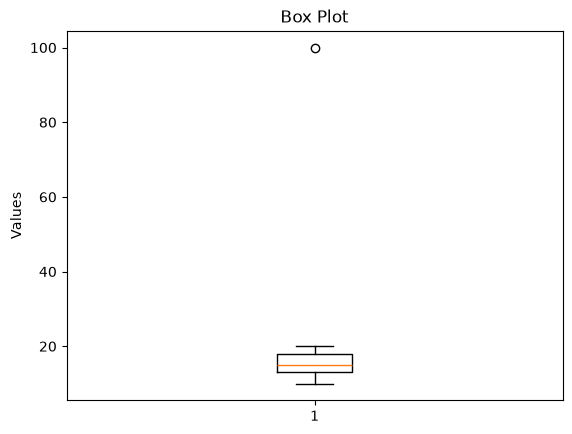

In [6]:
import matplotlib.pyplot as plt                 #pythonimplementation

data = [10, 12, 13, 14, 15, 16, 18, 20, 100]

plt.boxplot(data)

plt.title("Box Plot")
plt.ylabel("Values")

plt.show()

### Scatter Plot

In [ ]:
A scatter plot displays individual observations as points

The scatter plot helps you visually identify points that are far away from the general pattern

It is especially useful for finding unusual observations in two variables

Example:

Suppose we have:

Age       Salary
22        25000
25        30000
28        35000
30        40000
32        45000
50        200000

The last observation may be unusual compared with the overall pattern



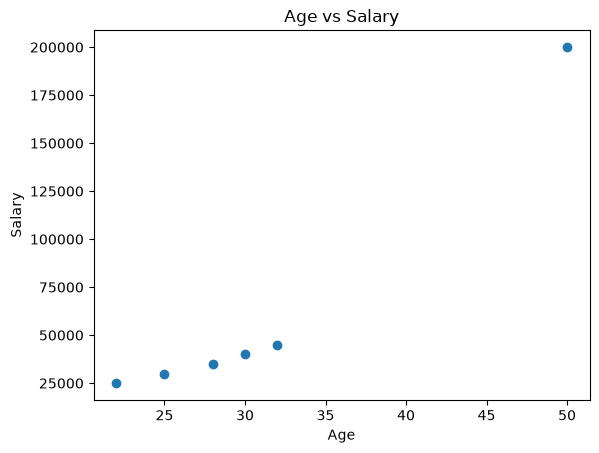

In [7]:
import matplotlib.pyplot as plt            #pythonimplementation

age = [22, 25, 28, 30, 32, 50]
salary = [25000, 30000, 35000, 40000, 45000, 200000]

plt.scatter(age, salary)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()